# ARIMA e SARIMA

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Na aula anterior montamos o **alfabeto** das séries temporais: tendência, sazonalidade, estacionariedade e a leitura de ACF e PACF. Agora vamos formar as primeiras **palavras**, com o modelo clássico de previsão: o ARIMA e a sua versão sazonal, o SARIMA.

Continuamos no mesmo contexto de **gestão da operadora**. Nosso caso condutor é o **volume de ligações na central de atendimento**, e o objetivo prático é claro: prever a demanda dos próximos dias para dimensionar a escala de atendentes com antecedência.

**Ao final desta aula você será capaz de:**

1. Explicar os três componentes do ARIMA (AR, I e MA) e o que cada um captura.
2. Entender por que o SARIMA é necessário quando existe sazonalidade.
3. Escolher os parâmetros $(p, d, q)$ e $(P, D, Q, s)$ de forma orientada por ACF, PACF e AIC.
4. Ajustar um SARIMA em Python, prever um período de teste e avaliar o resultado.

**Como usar este material:** execute as células na ordem. Após cada gráfico ou tabela há um bloco **Lendo o resultado**, que interpreta o que apareceu, ponto a ponto. Onde houver controles deslizantes, mexa neles e veja o modelo reagir. O ponto alto da aula é comparar, com os seus próprios olhos, um ARIMA que ignora a sazonalidade contra um SARIMA que a captura.


## 0. Preparação do ambiente

A célula abaixo garante as bibliotecas necessárias e define padrões visuais. Rode uma vez e siga em frente.


In [10]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "statsmodels", "ipywidgets"])

import warnings
warnings.filterwarnings("ignore")   # silencia avisos de convergencia do SARIMAX

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto. Bibliotecas carregadas com sucesso.")


Ambiente pronto. Bibliotecas carregadas com sucesso.


## Retomando a série da operadora

Para o notebook ser autossuficiente, recriamos a mesma série de ligações da aula anterior (a semente aleatória é a mesma, então os dados são idênticos). A diferença é o **nível de agregação**: aqui vamos trabalhar com o **total de ligações por dia**.

Por que passar de horária para diária? Por dois motivos práticos:

- O nosso objetivo agora é o **planejamento de escala com alguns dias de antecedência**, e a decisão de quantos atendentes escalar é tomada dia a dia.
- No nível diário, a **sazonalidade semanal** ($s = 7$) fica em primeiro plano, e o ajuste do modelo é rápido, o que deixa os experimentos interativos fluidos.

A mesma mecânica vale para dados horários com $s = 24$; a única diferença é o custo computacional, bem maior.


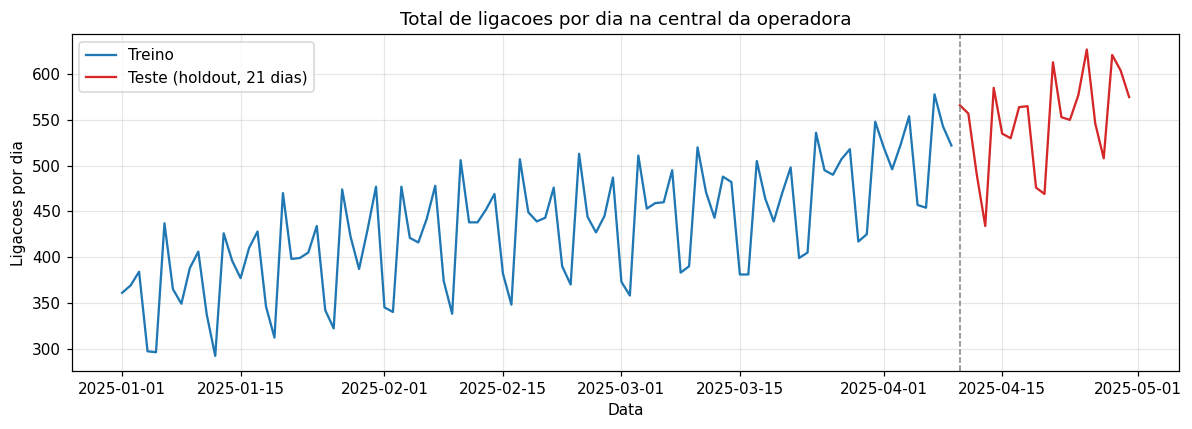

Total de dias: 120  |  treino: 99  |  teste: 21


In [11]:
# Perfil relativo de ligacoes por HORA DO DIA (call center) e por DIA DA SEMANA.
PERFIL_HORARIO = np.array([
    -8, -9, -9, -9, -8, -6, -3, 1, 5, 8, 9, 8,
     3,  2,  7,  8,  6,  3, -1, -3, -4, -5, -6, -7], dtype=float)
PERFIL_SEMANAL = np.array([3, 1, 0, 1, 2, -2, -3], dtype=float)

def gerar_serie_ligacoes(dias=120, base=15.0, tendencia=0.06,
                         amp_diaria=1.0, amp_semanal=1.0, ruido=1.8,
                         passeio=0.05, semente=SEMENTE):
    g = np.random.default_rng(semente)
    n = dias * 24
    indice = pd.date_range("2025-01-01", periods=n, freq="h")
    hora = indice.hour.to_numpy()
    dia_semana = indice.dayofweek.to_numpy()
    t = np.arange(n)
    nivel = base + tendencia * (t / 24) + np.cumsum(g.normal(0, passeio, size=n))
    valor = (nivel + amp_diaria * PERFIL_HORARIO[hora]
             + amp_semanal * PERFIL_SEMANAL[dia_semana] + g.normal(0, ruido, size=n))
    valor = np.clip(np.round(valor), 0, None)
    return pd.Series(valor, index=indice, name="n_ligacoes")

# Serie horaria (identica a da aula anterior) e agregacao diaria:
ligacoes_horaria = gerar_serie_ligacoes()
serie = ligacoes_horaria.resample("D").sum().asfreq("D")
serie.name = "ligacoes_dia"

# Separacao treino / teste: as ultimas 3 semanas (21 dias) sao o holdout.
N_TESTE = 21
treino, teste = serie.iloc[:-N_TESTE], serie.iloc[-N_TESTE:]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(treino.index, treino.values, color="#1f77b4", label="Treino")
ax.plot(teste.index, teste.values, color="#d62728", label="Teste (holdout, 21 dias)")
ax.axvline(teste.index[0], color="gray", ls="--", lw=1)
ax.set_title("Total de ligacoes por dia na central da operadora")
ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por dia"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Total de dias: {len(serie)}  |  treino: {len(treino)}  |  teste: {len(teste)}")


> **Lendo o gráfico.** É a mesma série da aula anterior, agora como **total por dia** (por isso os valores estão na casa das centenas). A parte **azul** são os **99 dias de treino**, com que o modelo vai aprender; a parte **vermelha** são os últimos **21 dias**, separados como **teste**, que o modelo não enxerga durante o ajuste. A linha tracejada marca a fronteira entre os dois períodos.
>
> Essa separação é a regra de ouro da avaliação honesta: só dá para saber se um modelo prevê bem comparando as previsões contra dados que ele nunca usou para aprender. Repare, desde já, no forte **serrilhado semanal**, que será o grande protagonista da aula.


## 3.1 Os três componentes do ARIMA, um de cada vez

A sigla **ARIMA($p, d, q$)** junta três ideias. Vamos ver uma de cada vez.

### AR: Autorregressivo ($p$)

A ideia do componente autorregressivo é direta: o valor de hoje pode ser explicado, em parte, como uma combinação linear dos valores anteriores da própria série. Um modelo AR($p$) usa as $p$ observações mais recentes como preditores:

$$ y*t = c + \phi_1\, y*{t-1} + \phi*2\, y*{t-2} + \ldots + \phi*p\, y*{t-p} + \varepsilon_t $$

Ou seja, o volume de ligações de hoje depende, com pesos $\phi$ diferentes, do volume de ontem, de anteontem, e assim por diante, até $p$ dias atrás. Quanto maior o $\phi$ de um lag, mais forte a **memória** da série naquele ponto do passado. O laboratório logo abaixo deixa essa ideia de memória palpável.


### Laboratório interativo: a memória do AR

Abaixo simulamos uma série AR(1), $y_t = \phi\, y_{t-1} + \varepsilon_t$, e mostramos ao lado a sua ACF. Mexa no controle $\phi$:

- com $\phi$ perto de zero, cada valor quase não depende do anterior (memória curta, a ACF cai na hora);
- com $\phi$ perto de 1, a série tem memória longa e a ACF decai devagar;
- com $\phi$ negativo, a série fica "serrilhada", alternando acima e abaixo da média.


In [12]:
from statsmodels.tsa.stattools import acf

try:
    from ipywidgets import interact, FloatSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

def laboratorio_ar1(phi=0.7):
    g = np.random.default_rng(1)
    n = 160
    y = np.zeros(n)
    ruidos = g.normal(0, 1, size=n)
    for t in range(1, n):
        y[t] = phi * y[t - 1] + ruidos[t]
    a = acf(y, nlags=20)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(y, color="#1f77b4")
    ax1.axhline(0, color="gray", lw=0.8)
    ax1.set_title(f"Serie AR(1) simulada com phi = {phi:.2f}")
    ax1.set_xlabel("Tempo"); ax1.set_ylabel("y")
    ax2.bar(range(len(a)), a, color="#ff7f0e")
    ax2.axhline(0, color="gray", lw=0.8)
    ax2.set_title("ACF: quanto maior o phi, mais longa a memoria")
    ax2.set_xlabel("Lag"); ax2.set_ylabel("Autocorrelacao"); ax2.set_ylim(-1, 1)
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(laboratorio_ar1,
             phi=FloatSlider(value=0.7, min=-0.95, max=0.95, step=0.05, description="phi"))
else:
    print("ipywidgets indisponivel; exibindo a versao estatica com phi = 0.7.")
    laboratorio_ar1()


interactive(children=(FloatSlider(value=0.7, description='phi', max=0.95, min=-0.95, step=0.05), Output()), _d…

> **Lendo os gráficos.** À esquerda, uma série AR(1) simulada; à direita, a sua ACF. Com o valor padrão **phi = 0,70**, cada valor puxa fortemente o próximo, então a série faz ondas suaves de subida e descida (a memória), e a ACF **decai gradualmente** ao longo dos lags.
>
> Experimente os extremos para fixar a intuição: com **phi próximo de 0**, a ACF cai de imediato (sem memória, cada ponto é quase independente do anterior); com **phi próximo de 0,95**, a ACF permanece alta por muitos lags (memória longa); com **phi negativo**, a série vira um zigue-zague e a ACF alterna de sinal. É assim que o parâmetro autorregressivo controla a persistência da série.


### I: Integrado ($d$)

Como vimos na Seção 2.3, o componente AR só é bem-comportado quando a série é **estacionária**. O componente **I** resolve isso aplicando **diferenciação**: em vez de modelar a série original, modela-se a variação de um período para o outro, $y_t - y_{t-1}$. O parâmetro $d$ diz **quantas vezes** essa diferenciação é aplicada. Na prática, $d = 0$ (série já estacionária) ou $d = 1$ (uma diferença resolve) cobre a grande maioria dos casos.

### MA: Média Móvel ($q$)

O componente de média móvel tem um nome que engana: ele **não** é uma média móvel dos valores passados, e sim uma combinação linear dos **erros de previsão** passados. A intuição é: se o modelo errou para mais ontem, é provável que ainda esteja arrastando um pouco desse erro hoje. Um modelo MA($q$) usa os $q$ erros mais recentes:

$$ y*t = c + \varepsilon_t + \theta_1\, \varepsilon*{t-1} + \ldots + \theta*q\, \varepsilon*{t-q} $$

Juntando tudo, um **ARIMA($p, d, q$)** diferencia a série $d$ vezes e depois modela o resultado como uma combinação de $p$ termos autorregressivos e $q$ termos de média móvel dos erros.


## 3.2 SARIMA: adicionando a sazonalidade

A nossa série de ligações tem uma **sazonalidade semanal** forte: uma segunda-feira se parece muito mais com outras segundas do que com um domingo. O ARIMA puro não captura isso de forma nativa, porque ele só olha para os lags imediatamente anteriores.

O **SARIMA** resolve adicionando um segundo conjunto de parâmetros **sazonais**, notados $(P, D, Q, s)$:

- $s$ é o **período** do ciclo sazonal: $7$ para dado diário com padrão semanal, $24$ para dado horário com padrão diário.
- $P$, $D$ e $Q$ são as versões **sazonais** dos mesmos AR, I e MA, aplicadas não ao lag anterior, mas ao lag $s$ períodos atrás (uma semana atrás, no nosso caso).

A notação completa é $\text{SARIMA}(p, d, q)(P, D, Q)[s]$. Por exemplo, o modelo $\text{ARIMA}(3,0,0)(2,1,0)[24]$ usado por Choudhury (2019) para prever chegadas horárias tem 3 termos autorregressivos não sazonais e, na parte sazonal, 2 termos autorregressivos e uma diferenciação sazonal, com ciclo de 24 horas.

O gráfico abaixo confirma a sazonalidade semanal da nossa série: na ACF da série **diferenciada**, o pico salta exatamente no lag 7 e no lag 14. É essa assinatura que justifica usar $s = 7$.


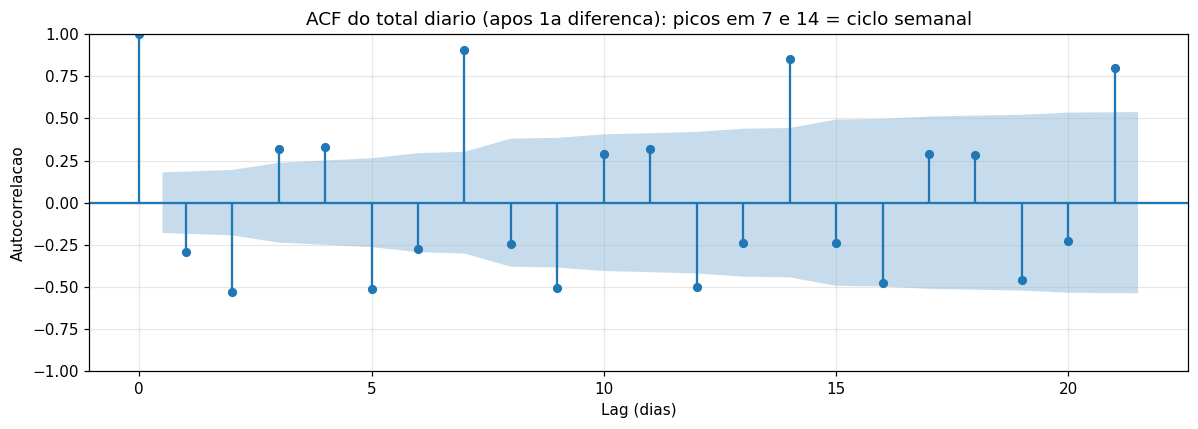

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(serie.diff().dropna(), lags=21, ax=ax)
ax.set_title("ACF do total diario (apos 1a diferenca): picos em 7 e 14 = ciclo semanal")
ax.set_xlabel("Lag (dias)"); ax.set_ylabel("Autocorrelacao")
plt.tight_layout(); plt.show()


> **Lendo o gráfico.** Esta é a ACF do **total diário já diferenciado**. O que salta aos olhos são os **picos altos exatamente nos lags 7 e 14** (correlações de cerca de **0,91 e 0,85**), muito acima da faixa azul de confiança. Traduzindo: cada dia se parece fortemente com o mesmo dia da semana anterior e da retrasada.
>
> Essa é a prova numérica da sazonalidade semanal e a justificativa direta para usar **$s = 7$** no SARIMA. Um ARIMA comum, que só olha os lags vizinhos (1, 2, 3 dias), não teria como aproveitar essa informação de "uma semana atrás".


## 3.3 Como escolher $p$, $d$, $q$ na prática

Não se escolhe a ordem no chute. A receita clássica, conhecida como metodologia de Box-Jenkins, é:

1. **Verificar a estacionariedade** com o teste ADF (Seção 2.3). Se a série não for estacionária, diferenciar (aumentar $d$) até estabilizar. O mesmo vale para a diferença sazonal ($D$).
2. **Olhar a PACF**: o lag em que ela corta abruptamente sugere o valor de $p$.
3. **Olhar a ACF**: o lag em que ela corta abruptamente sugere o valor de $q$.
4. **Comparar candidatos por um critério de informação**, o **AIC** (Akaike Information Criterion) ou o **BIC**, que penalizam modelos com parâmetros demais. Entre dois modelos, prefere-se o de **menor AIC**.

Na prática profissional, o passo 4 costuma ser automatizado por bibliotecas como o `pmdarima` (a famosa técnica de **auto-ARIMA**), que testam muitas combinações e escolhem a de menor AIC. Abaixo fazemos uma versão enxuta e transparente dessa busca: fixamos a parte sazonal e varremos algumas combinações de $(p, d, q)$, ordenando pelo AIC.


In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

candidatos = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            modelo = SARIMAX(treino, order=(p, 1, q), seasonal_order=(1, 1, 1, 7),
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            candidatos.append({"p": p, "d": 1, "q": q, "AIC": modelo.aic})
        except Exception:
            pass

ranking = pd.DataFrame(candidatos).sort_values("AIC").reset_index(drop=True)
melhor_pdq = (int(ranking.iloc[0]["p"]), int(ranking.iloc[0]["d"]), int(ranking.iloc[0]["q"]))

ranking_exibir = ranking.assign(
    ordem=ranking.apply(lambda r: f"({r.p:.0f},{r.d:.0f},{r.q:.0f})(1,1,1)[7]", axis=1)
)[["ordem", "AIC"]]
print("Candidatos ordenados por AIC (menor e melhor):")
print(ranking_exibir.to_string(index=False))
print(f"\nModelo escolhido pelo AIC: SARIMA{melhor_pdq}(1,1,1)[7]")


Candidatos ordenados por AIC (menor e melhor):
            ordem        AIC
(0,1,2)(1,1,1)[7] 641.965781
(1,1,2)(1,1,1)[7] 643.113896
(2,1,0)(1,1,1)[7] 648.808518
(0,1,1)(1,1,1)[7] 649.601748
(2,1,2)(1,1,1)[7] 649.611188
(1,1,1)(1,1,1)[7] 653.021136
(2,1,1)(1,1,1)[7] 655.020778
(1,1,0)(1,1,1)[7] 660.534784
(0,1,0)(1,1,1)[7] 692.757544

Modelo escolhido pelo AIC: SARIMA(0, 1, 2)(1,1,1)[7]


> **Lendo a tabela.** Cada linha é um candidato de ordem $(p, d, q)$ com a mesma parte sazonal, ordenado do **menor AIC (melhor) para o maior (pior)**. O AIC recompensa o ajuste aos dados e penaliza parâmetros em excesso, então serve para comparar modelos de forma justa.
>
> O topo da lista é **$(0,1,2)(1,1,1)[7]$, com AIC de cerca de 642**, e é esse modelo que o código seleciona automaticamente. A diferença para o pior candidato da lista (AIC perto de 693) confirma que a escolha das ordens tem impacto real. Note um detalhe interessante: o melhor modelo tem $p = 0$, ou seja, aqui os termos de média móvel $(q = 2)$ explicam melhor do que os autorregressivos.


## 3.4 Implementação em Python: ARIMA contra SARIMA

Agora o momento mais importante da aula. Vamos ajustar **dois** modelos no conjunto de treino e prever as 3 semanas de teste:

- um **ARIMA($2, 1, 2$)**, que ignora a sazonalidade;
- o **SARIMA** eleito pelo AIC no passo anterior, com a parte sazonal $(1, 1, 1)[7]$, que a captura.

Depois comparamos os dois com três métricas de erro (detalhadas na Seção 12):

- **MAE** (erro absoluto médio): o erro típico, na mesma unidade da série (ligações por dia).
- **RMSE** (raiz do erro quadrático médio): penaliza mais os erros grandes.
- **MAPE** (erro percentual absoluto médio): o erro em termos relativos, fácil de comunicar à gestão.


In [15]:
def metricas(y_real, y_prev):
    y_real = np.asarray(y_real, dtype=float)
    y_prev = np.asarray(y_prev, dtype=float)
    erro = y_real - y_prev
    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro ** 2))
    mape = np.mean(np.abs(erro / y_real)) * 100
    return mae, rmse, mape

# Modelo 1: ARIMA puro (sem sazonalidade)
arima = SARIMAX(treino, order=(2, 1, 2), seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
prev_arima = arima.get_forecast(steps=N_TESTE).predicted_mean

# Modelo 2: SARIMA (com sazonalidade semanal), na ordem eleita pelo AIC
sarima = SARIMAX(treino, order=melhor_pdq, seasonal_order=(1, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
prev_sarima = sarima.get_forecast(steps=N_TESTE)
media_sarima = prev_sarima.predicted_mean
ic_sarima = prev_sarima.conf_int()

rotulo_sarima = f"SARIMA{melhor_pdq}(1,1,1)[7]"
tabela = pd.DataFrame(
    [("ARIMA(2,1,2)", arima.aic, *metricas(teste, prev_arima)),
     (rotulo_sarima, sarima.aic, *metricas(teste, media_sarima))],
    columns=["Modelo", "AIC", "MAE", "RMSE", "MAPE (%)"],
)
print(tabela.round(2).to_string(index=False))
print("\nQuanto menor cada numero, melhor. Repare na diferenca entre as duas linhas.")


                   Modelo     AIC   MAE  RMSE  MAPE (%)
             ARIMA(2,1,2) 1003.68 53.91 61.11      9.66
SARIMA(0, 1, 2)(1,1,1)[7]  641.97 14.93 18.07      2.80

Quanto menor cada numero, melhor. Repare na diferenca entre as duas linhas.


> **Lendo a tabela.** As duas linhas contam a história da aula inteira. Todas as colunas seguem a regra "menor é melhor".
>
> - **ARIMA(2,1,2)**, que ignora a semana: erra em média **53,9 ligações por dia** (MAE), com **MAPE de 9,7%**, e AIC de cerca de 1004.
> - **SARIMA(0,1,2)(1,1,1)[7]**, que captura a semana: erra apenas **14,9 ligações por dia**, com **MAPE de 2,8%**, e AIC de cerca de 642.
>
> Traduzindo: adicionar a sazonalidade **cortou o erro para menos de um terço** e o MAPE de quase 10% para menos de 3%. Para a operação, é a diferença entre uma escala de atendentes que erra feio nas segundas-feiras e uma que acerta o padrão da semana. O gráfico a seguir mostra isso visualmente.


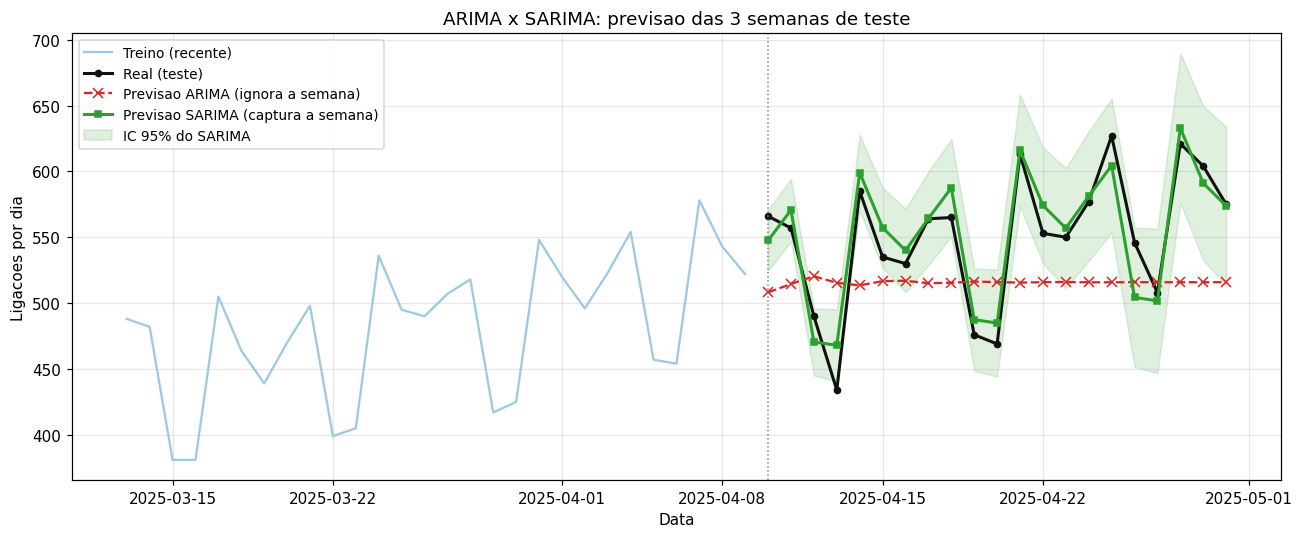

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

# Contexto: ultimas semanas do treino
contexto = treino.iloc[-28:]
ax.plot(contexto.index, contexto.values, color="#9ecae1", label="Treino (recente)")
ax.plot(teste.index, teste.values, color="#111111", lw=2, marker="o", ms=4, label="Real (teste)")
ax.plot(teste.index, prev_arima.values, color="#d62728", ls="--", marker="x",
        label="Previsao ARIMA (ignora a semana)")
ax.plot(teste.index, media_sarima.values, color="#2ca02c", lw=2, marker="s", ms=4,
        label="Previsao SARIMA (captura a semana)")
ax.fill_between(teste.index, ic_sarima.iloc[:, 0], ic_sarima.iloc[:, 1],
                color="#2ca02c", alpha=0.15, label="IC 95% do SARIMA")

ax.axvline(teste.index[0], color="gray", ls=":", lw=1)
ax.set_title("ARIMA x SARIMA: previsao das 3 semanas de teste")
ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por dia"); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()


> **Lendo o gráfico.** A linha **preta** é a demanda real das 3 semanas de teste. A linha **vermelha tracejada** é a previsão do ARIMA puro: repare que ela é quase **reta, sem ondas**, porque o modelo não enxerga a semana e aposta em um nível médio, errando de forma sistemática os picos e os vales. A linha **verde** é a previsão do SARIMA: ela **acompanha as subidas e descidas semanais**, colada na curva real. A faixa verde clara é o **intervalo de confiança de 95%**, a margem de incerteza declarada pelo modelo.
>
> Este é o retrato do que os números da tabela anterior já diziam: o SARIMA reproduz o ritmo da operação, o ARIMA apenas a média dela.


### O modelo é bom? Olhando os resíduos

Um bom modelo deixa para trás resíduos (os erros de ajuste) que se parecem com **ruído branco**: sem padrão, sem autocorrelação sobrando e aproximadamente normais. Se ainda houver estrutura nos resíduos, é sinal de que o modelo deixou informação na mesa. O `statsmodels` resume esse diagnóstico em quatro gráficos.

O que procurar: no gráfico de cima à esquerda, resíduos oscilando em torno de zero sem tendência; no histograma e no gráfico Q-Q, algo próximo de uma normal; e, no correlograma (ACF dos resíduos), nenhuma barra relevante fora da faixa azul, em especial no lag 7.


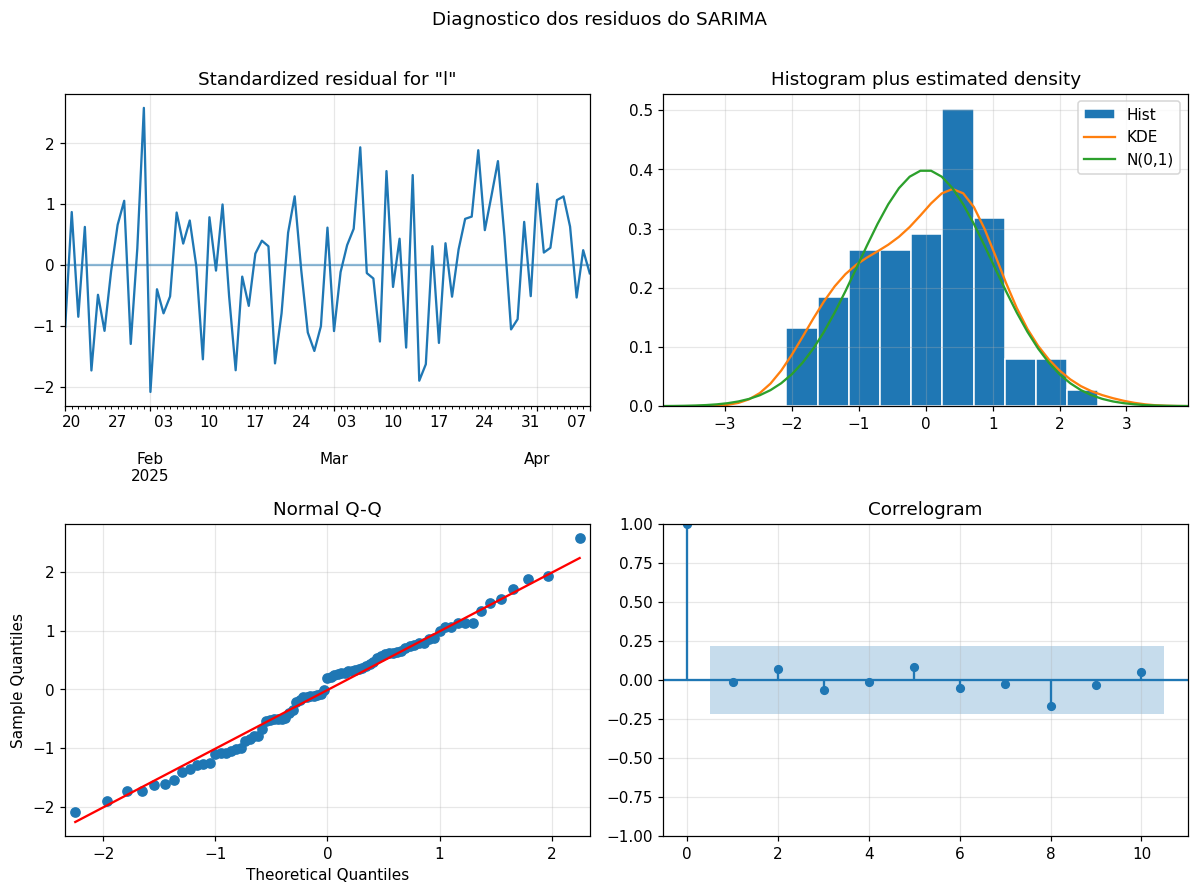

In [17]:
fig = sarima.plot_diagnostics(figsize=(11, 8))
fig.suptitle("Diagnostico dos residuos do SARIMA", y=1.01)
plt.tight_layout(); plt.show()


> **Lendo os quatro gráficos.** Este painel investiga os **resíduos** (os erros que o modelo deixou para trás). Um bom modelo deixa resíduos parecidos com **ruído branco**, sem padrão aproveitável.
>
> - **Standardized residual** (topo esquerdo): oscila em torno de zero, sem tendência nem funil, sinal de variância estável ao longo do tempo.
> - **Histogram + estimated density** (topo direito): a distribuição dos resíduos acompanha de perto a curva normal de referência.
> - **Normal Q-Q** (base esquerdo): os pontos caem quase todos sobre a diagonal, outra confirmação de normalidade.
> - **Correlogram** (base direito): a ACF dos resíduos, com as barras dentro (ou muito perto) da faixa azul, **inclusive no lag 7**. Isso é o mais importante: significa que o modelo **absorveu toda a estrutura semanal** e não deixou informação para trás.
>
> Diagnóstico aprovado: os resíduos se comportam como ruído (os testes de Ljung-Box e Jarque-Bera, sobre estes resíduos, dão p-valores altos, confirmando ausência de autocorrelação e normalidade). Podemos confiar nas previsões do SARIMA.


## Laboratório interativo: monte o seu próprio modelo

Agora é a sua vez de assumir o papel de Box e Jenkins. Ajuste as ordens não sazonais $(p, d, q)$ e ligue ou desligue a **sazonalidade semanal**. A cada mudança, o modelo é reajustado no treino e previsto no teste, e o título mostra o AIC, o MAE e o MAPE resultantes.

Sugestão de roteiro: comece com a sazonalidade **desligada** e tente melhorar o MAPE apenas com $(p, d, q)$. Depois **ligue** a sazonalidade e observe o erro despencar. É a demonstração mais direta de por que o SARIMA existe.


In [18]:
try:
    from ipywidgets import interact, IntSlider, Checkbox
    _INTERATIVO2 = True
except ImportError:
    _INTERATIVO2 = False

def construir_modelo(p=1, d=1, q=1, sazonalidade_semanal=True):
    ordem_sazonal = (1, 1, 1, 7) if sazonalidade_semanal else (0, 0, 0, 0)
    try:
        modelo = SARIMAX(treino, order=(p, d, q), seasonal_order=ordem_sazonal,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        previsao = modelo.get_forecast(steps=N_TESTE).predicted_mean
        mae, rmse, mape = metricas(teste, previsao)
        rotulo = "SARIMA" if sazonalidade_semanal else "ARIMA"
        titulo = (f"{rotulo}({p},{d},{q})"
                  + (f"(1,1,1)[7]" if sazonalidade_semanal else "")
                  + f"   |   AIC = {modelo.aic:.0f}   |   MAE = {mae:.1f}   |   MAPE = {mape:.1f}%")
    except Exception as erro:
        titulo = f"Este modelo nao convergiu ({type(erro).__name__}). Tente outra combinacao."
        previsao = None

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(treino.iloc[-21:].index, treino.iloc[-21:].values, color="#9ecae1", label="Treino")
    ax.plot(teste.index, teste.values, color="#111111", lw=2, marker="o", ms=4, label="Real")
    if previsao is not None:
        ax.plot(teste.index, previsao.values, color="#2ca02c", lw=2, marker="s", ms=4, label="Previsao")
    ax.set_title(titulo)
    ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por dia"); ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout(); plt.show()

if _INTERATIVO2:
    interact(construir_modelo,
             p=IntSlider(value=1, min=0, max=3, description="p (AR)"),
             d=IntSlider(value=1, min=0, max=2, description="d (I)"),
             q=IntSlider(value=1, min=0, max=3, description="q (MA)"),
             sazonalidade_semanal=Checkbox(value=True, description="Sazonalidade semanal (s=7)"))
else:
    print("ipywidgets indisponivel; comparando ARIMA e SARIMA de forma estatica.")
    construir_modelo(sazonalidade_semanal=False)
    construir_modelo(sazonalidade_semanal=True)


interactive(children=(IntSlider(value=1, description='p (AR)', max=3), IntSlider(value=1, description='d (I)',…

> **O que observar.** Na configuração padrão (sazonalidade **ligada**), a previsão verde já cola na curva real e o título exibe um MAPE baixo. Agora faça o experimento central da aula: **desligue** o checkbox de sazonalidade. A previsão vira quase uma reta e o MAPE dispara. Ao ligar de novo, ele despenca. Em poucos cliques você reproduz, com o seu próprio modelo, a razão de existir do SARIMA. Vale também variar $p$ e $q$ com a sazonalidade ligada e reparar que o ganho fino é bem menor do que o salto de ligar a parte sazonal.


## Síntese, limitações e próximo passo

O que esta aula deixou claro, número na mão: quando a série tem sazonalidade, **ignorá-la custa caro**. O ARIMA puro erra bem mais do que o SARIMA no mesmo período de teste, e o AIC confirma a diferença. O parâmetro sazonal $(P, D, Q, s)$ é o que transforma um modelo cego à semana em um modelo que antecipa a segunda-feira cheia.

**Quando usar ARIMA / SARIMA na operadora:** são uma excelente linha de base, estatisticamente sólida e barata de rodar, para séries com uma sazonalidade dominante, como volume de ligações, teleconsultas ou solicitações de autorização prévia.

**Limitações que motivam os próximos módulos:**

- Exigem que a série seja estacionária ou tornada estacionária por diferenciação.
- Lidam de forma limitada com **múltiplas sazonalidades simultâneas** (diária e semanal ao mesmo tempo, por exemplo).
- Não incorporam variáveis externas de forma nativa, embora a variante **SARIMAX** aceite regressores exógenos pelo parâmetro `exog` (feriados, campanhas, indicadores epidemiológicos).

Na literatura, esse é justamente o limite observado: Feng et al. (2022) encontraram o SARIMA com a menor acurácia entre três modelos comparados para prever internações, atrás de Prophet e LSTM. Ainda assim, o ARIMA segue relevante e acessível como ponto de partida, como documenta Sato (2013) na revista Einstein sobre o uso de ARIMA na gestão de saúde no Brasil.

Na **Seção 4** damos o próximo passo com o **Prophet**, que trata tendência, múltiplas sazonalidades e feriados de forma explícita e amigável, endereçando parte dessas limitações.

---

**Referências**

- Choudhury, A. (2019). Forecasting hourly emergency department arrivals.
- Feng, X. et al. (2022). Comparação de SARIMA, Prophet e LSTM para previsão de internações.
- Sato, R. C. (2013). Análise de séries temporais com ARIMA na gestão de doenças. _Einstein_.
- Hyndman, R. J.; Athanasopoulos, G. (2021). _Forecasting: Principles and Practice_, 3ª edição.
